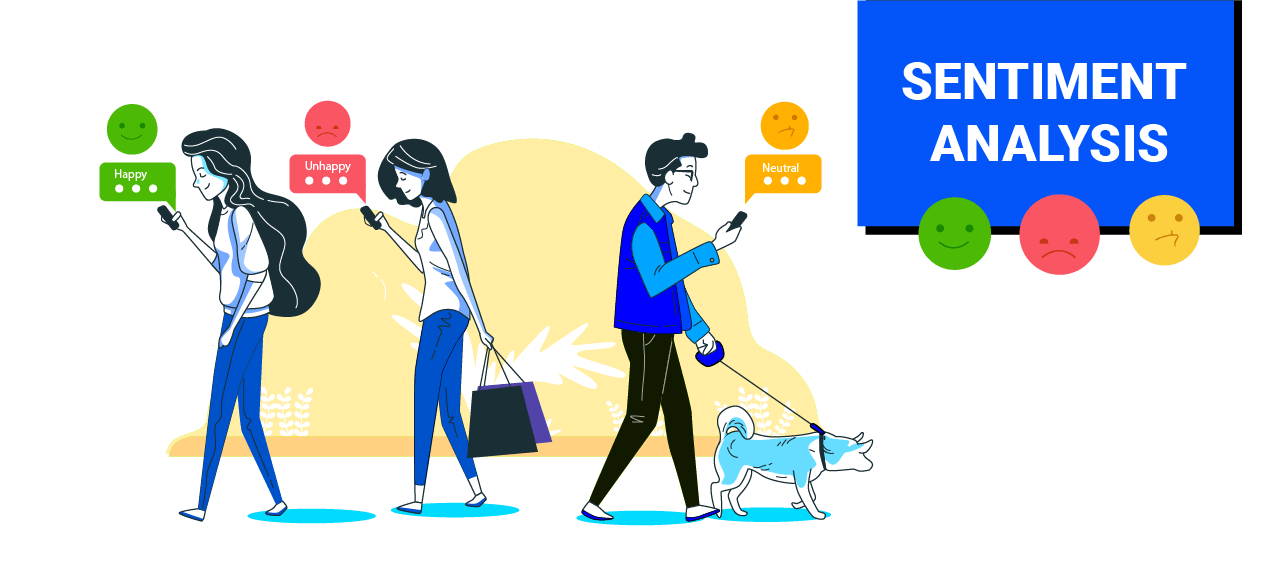

* <b> Overview :</b> Explore text-based emotion recognition, a dynamic field in <span style="background-color: #F8DE22; padding: 4px; border-radius:5px;">NLP</span>, focusing on deciphering diverse emotional states in textual content.

* <b> Objective :</b> Build a system for automatic categorization of text into six emotions 
( <span style="color: #F8DE22;">joy</span>  , 
 <span style="color: #0c0d49;">sadness</span> , 
 <span style="color: #b82f2f;">fear</span> , 
 <span style="color: #331e1e;">anger</span > , 
 <span style="color: red;">love</span> , 
 <span style="color: #00fff7;">surprise</span>)
* <b> Model Choice : </b> Utilize <span style="background-color: #F8DE22; padding: 4px; border-radius:5px;">LSTM</span>
 (Long Short-Term Memory) networks, a type of <span style="background-color: #F8DE22; padding: 4px; border-radius:5px;">RNN</span>.
 
* <b> Implementation : </b>
Implemented with <span style="background-color: #F8DE22; padding: 4px; border-radius:5px;">TensorFlow</span>.



In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.stem import PorterStemmer
import numpy as np
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix


import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


# 1 | The Dataset

* any data sets involving sentiment analysis are <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">binary classification</span> problems
* In this dataset we have <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">6 different sentiments</span> , which means we'll be treating this problem as a <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">multiclass classification</span> problem

   ### 1. 1 | Loading Data 

In [2]:
val_data = pd.read_csv('validation.csv')
train_data = pd.read_csv('training.csv')
test_data = pd.read_csv('test.csv')

In [3]:
print("Validation data :",val_data.shape)
print("Train data :",train_data.shape)
print("Test data :",test_data.shape)

Validation data : (2000, 2)
Train data : (16000, 2)
Test data : (2000, 2)


* There is a lot of data in test, in my case i divided it and put the est in the val_data 

In [4]:
half_test_data = test_data.iloc[1000:]
test_data = test_data.iloc[:1000]

val_data = pd.concat([val_data, half_test_data], axis=0)

print("new Vald data :",val_data.shape)
print("new Test data :",test_data.shape)

new Vald data : (3000, 2)
new Test data : (1000, 2)


In [5]:
train_data.head(10)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


### 1. 2 | Adding Label Data

In [6]:
labels_dict = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
train_data['label_name'] = train_data['label'].map(labels_dict)
train_data.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [7]:
train_data.groupby(["label_name","label"]).size()

label_name  label
anger       3        2159
fear        4        1937
joy         1        5362
love        2        1304
sadness     0        4666
surprise    5         572
dtype: int64

### 1. 3 | Data Visualization

<Axes: xlabel='label_name'>

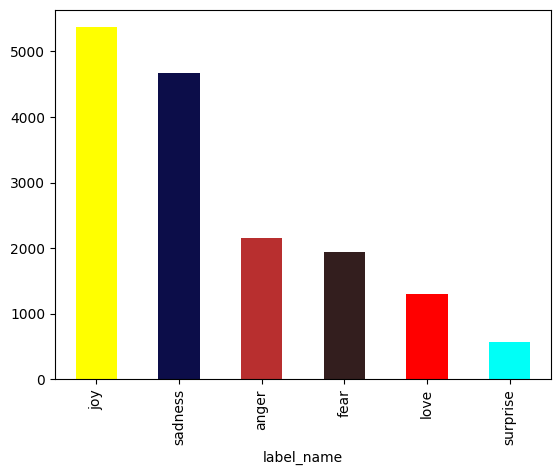

In [8]:
train_data["label_name"].value_counts().plot(kind='bar',color=['yellow', '#0c0d49', '#b82f2f', '#331e1e', 'red','#00fff7'])

# 2 | Data Cleaning

In [9]:
print(train_data.isnull().sum())
print(val_data.isnull().sum())
print(test_data.isnull().sum())

text          0
label         0
label_name    0
dtype: int64
text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


# 3 | Tokenisation & Stemming

* <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">Tokenization</span> assigns unique IDs to words, creating a word index or vocabulary.
* <b>Example Sentence :</b> "Tokenization is essential for NLP tasks."
* <b>Tokenized Output : </b>['Tokenization', 'is', 'essential', 'for', 'NLP', 'tasks', '.']


* <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">Stemming</span> is a technique used to reduce an inflected word down to its word stem.
* <b>Example :</b> 
* <b>Original Words :</b> running , programming , swimming , happiness , programmer <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">  (5 words)</span>
* <b>Stemmed Words :</b> run , program , swim , happi   <span style="background-color: #F8DE22; padding: 2px; border-radius:5px;">  (4 words)</span>

In [10]:
all_list = train_data['text'].tolist() + test_data['text'].tolist() + val_data['text'].tolist()

In [11]:
tokenizer1 = Tokenizer()
tokenizer1.fit_on_texts(all_list)
word_index1 = tokenizer1.word_index

print("Nombre of words without Stemming:",len(word_index1))

stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in word_index1.keys()]

tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts(stemmed_words)
word_index2 = tokenizer2.word_index

print("Nombre of words with Stemming:",len(word_index2))

Nombre of words without Stemming: 17096
Nombre of words with Stemming: 11705


* load all data to list : <b>[ [ Tokenised_Data ] , label ] </b>

In [12]:
def preprocess_data(data):
    new_data = []
    for index, row in data.iterrows():
        test_split = row['text'].split()
        stemmed_words2 = [stemmer.stem(word) for word in test_split]
        token_list= tokenizer2.texts_to_sequences([stemmed_words2])[0]
        new_data.append([token_list,row['label']]) 
    return new_data

In [13]:
new_train_data = preprocess_data(train_data)
print(train_data['text'][0])
print(new_train_data[0])    

i didnt feel humiliated
[[3198, 3265, 220, 665], 0]


In [14]:
new_val_data = preprocess_data(val_data)
print(val_data['text'][0])
print(new_val_data[0])    

im feeling quite sad and sorry for myself but ill snap out of it soon
[[3205, 220, 595, 1335, 3199, 3326, 3206, 3227, 3207, 1326, 518, 1283, 1274, 1276, 3380], 0]


In [15]:
# Splitting into train_X and train_y
train_X = [row[0] for row in new_train_data]
train_y = [row[1] for row in new_train_data]

# Print the results
print("train_X:", train_X[0])
print("train_y:", train_y[0])

train_X: [3198, 3265, 220, 665]
train_y: 0


In [16]:
val_X = [row[0] for row in new_val_data]
val_y = [row[1] for row in new_val_data]

print("train_X:", val_X[0])
print("train_y:", val_y[0])

train_X: [3205, 220, 595, 1335, 3199, 3326, 3206, 3227, 3207, 1326, 518, 1283, 1274, 1276, 3380]
train_y: 0


### 3. 2 | Add Padding

In [17]:
length_of_longest_sentence = len(max(train_X, key=len))
print(length_of_longest_sentence)
print(max(train_X, key=len))

66
[3198, 613, 3250, 3588, 3217, 3204, 3198, 927, 3245, 1497, 3245, 1354, 3217, 3245, 1303, 1296, 3200, 2107, 1284, 1276, 3220, 220, 3598, 3213, 220, 1276, 3528, 3217, 7890, 4263, 3221, 5569, 1552, 3243, 3198, 4263, 3221, 1552, 5570, 5570, 3198, 3579, 5569, 3198, 7891, 1276, 3200, 3202, 1293, 3219, 1401, 3948, 3598, 3213, 3223, 239, 3528, 3213, 85, 3267, 579, 1658, 3206, 3201, 239, 1289]


In [18]:
for i in range(len(train_X)):
    for j in range(length_of_longest_sentence-len(train_X[i])):
        train_X[i].append(0)
        
for i in range(len(val_X)):
    for j in range(length_of_longest_sentence-len(val_X[i])):
        val_X[i].append(0)

### 3. 3 | List to Array (numpy)

In [19]:
train_X = np.array(train_X)
train_y = np.array(train_y)
val_X = np.array(val_X)
val_y = np.array(val_y)

print(train_X.shape,train_y.shape)
print(val_X.shape,val_y.shape)


(16000, 66) (16000,)
(3000, 66) (3000,)


In [20]:
# Convert labels to one-hot encoding
train_y_one_hot = to_categorical(train_y, num_classes=16000)
val_y_one_hot = to_categorical(val_y, num_classes=16000)

# 4 | Create model (LSTM)

### 4. 1 | Architechture of Bidirectional LSTM Neural Network

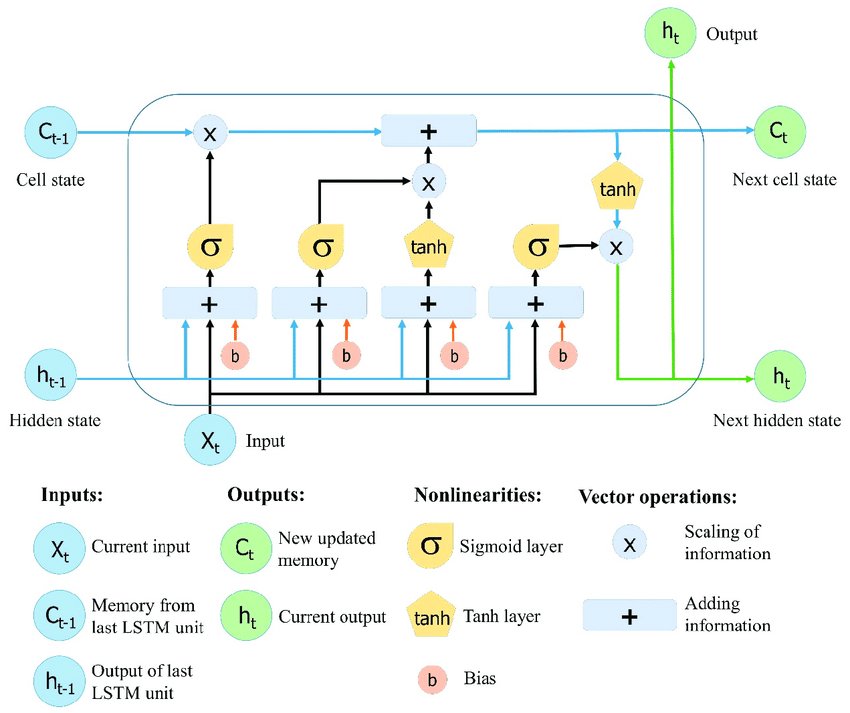

### 4. 2 | Bi- LSTM Neural Network Model training

In [21]:
model = Sequential()
model.add(Embedding(16000, 100))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(16000, activation='softmax'))
adam = Adam(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history = model.fit(train_X, train_y_one_hot, epochs=25, verbose=1, validation_data=(val_X, val_y_one_hot))
print(model.summary())


Epoch 1/25
500/500 [==============================] - 145s 267ms/step - loss: 1.7655 - accuracy: 0.2944 - val_loss: 1.6715 - val_accuracy: 0.3540
Epoch 2/25
500/500 [==============================] - 127s 253ms/step - loss: 1.6801 - accuracy: 0.3053 - val_loss: 1.6072 - val_accuracy: 0.3450
Epoch 3/25
500/500 [==============================] - 129s 258ms/step - loss: 1.5710 - accuracy: 0.3667 - val_loss: 1.4595 - val_accuracy: 0.4500
Epoch 4/25
500/500 [==============================] - 132s 264ms/step - loss: 1.1961 - accuracy: 0.5681 - val_loss: 0.9770 - val_accuracy: 0.6690
Epoch 5/25
500/500 [==============================] - 133s 266ms/step - loss: 0.7395 - accuracy: 0.7423 - val_loss: 0.6269 - val_accuracy: 0.7853
Epoch 6/25
500/500 [==============================] - 130s 260ms/step - loss: 0.5339 - accuracy: 0.8166 - val_loss: 0.5598 - val_accuracy: 0.8147
Epoch 7/25
500/500 [==============================] - 126s 252ms/step - loss: 0.4454 - accuracy: 0.8455 - val_loss: 0.4982 -

# 5 | Resultd And Test

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model on the validation set
val_predictions = model.predict(val_X)
val_predictions = np.argmax(val_predictions, axis=1)
val_true = np.argmax(val_y_one_hot, axis=1)

# Calculate accuracy
accuracy = accuracy_score(val_true, val_predictions)
print("Accuracy:", accuracy)

# Calculate precision
precision = precision_score(val_true, val_predictions, average='weighted')
print("Precision:", precision)

# Calculate recall
recall = recall_score(val_true, val_predictions, average='weighted')
print("Recall:", recall)

# Calculate F1-score
f1 = f1_score(val_true, val_predictions, average='weighted')
print("F1-score:", f1)


94/94 [==============================] - 7s 69ms/step
Accuracy: 0.8763333333333333
Precision: 0.8772853353394445
Recall: 0.8763333333333333
F1-score: 0.8762625039274655


In [24]:
last_accuracy = "{:.3f}".format(history.history['accuracy'][-1])
print("Training Accuracy:", last_accuracy)

Training Accuracy: 0.937


### 5. 1 | Plotting Model Accuracy And Loss

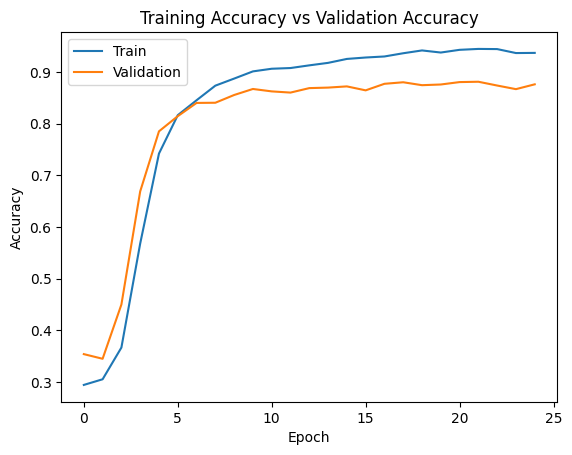

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy vs Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

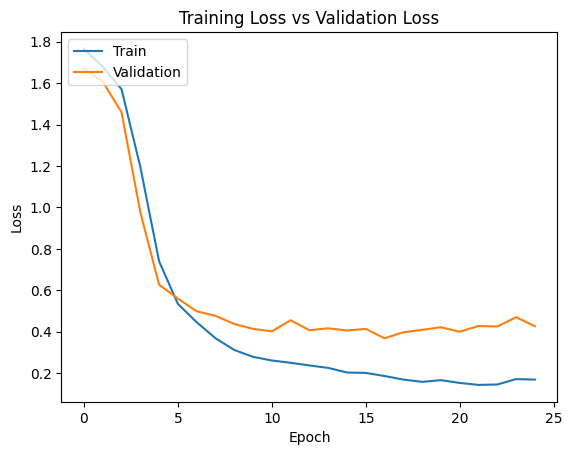

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Loss vs Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### 5. 2 | Test The Model

In [27]:
def get_text(text):
    tokenizer3 = Tokenizer()
    tokenizer3.fit_on_texts(text)
    word_index3 = tokenizer3.word_index
    
    stemmed_wordss = [stemmer.stem(word) for word in word_index3.keys()]
   
    tokens_list= tokenizer2.texts_to_sequences([stemmed_wordss])[0]

    for i in range(len(tokens_list)):
        for j in range(length_of_longest_sentence-len(tokens_list)):
            tokens_list.append(0)
    return tokens_list


In [28]:
for _ in range(5):
    random_number = random.randint(0, 1000)
    num_to_predicte = random_number

    test = get_text([test_data['text'][num_to_predicte]])

    test = np.array(test)
    test = test.reshape(1, len(test))

    # Make predictions
    predictions = model.predict(test)

    predicted_class = np.argmax(predictions)
    print()
    print('Random value = ',random_number)
    print("Predicted Class:", predicted_class,labels_dict.get(predicted_class))
    print("Actual Class:", test_data['label'][num_to_predicte])
    print()

1/1 [==============================] - 4s 4s/step

Random value =  90
Predicted Class: 1 joy
Actual Class: 1

1/1 [==============================] - 0s 43ms/step

Random value =  69
Predicted Class: 5 surprise
Actual Class: 5

1/1 [==============================] - 0s 35ms/step

Random value =  434
Predicted Class: 4 fear
Actual Class: 4

1/1 [==============================] - 0s 38ms/step

Random value =  414
Predicted Class: 3 anger
Actual Class: 3

1/1 [==============================] - 0s 27ms/step

Random value =  974
Predicted Class: 0 sadness
Actual Class: 0



### 5. 2 | Confusion Matrix

In [29]:
new_test_data=preprocess_data(test_data)

test_X = [row[0] for row in new_train_data]
test_y = [row[1] for row in new_train_data]

for i in range(len(test_X)):
    for j in range(length_of_longest_sentence-len(test_X[i])):
        test_X[i].append(0)
        
test_X = np.array(test_X) 
test_y = np.array(test_y)  

test_y_one_hot = to_categorical(test_y, num_classes=16000)

In [30]:
y_pred = model.predict(test_X)
y_pred_classes = np.argmax(y_pred, axis=1)

500/500 [==============================] - 52s 102ms/step


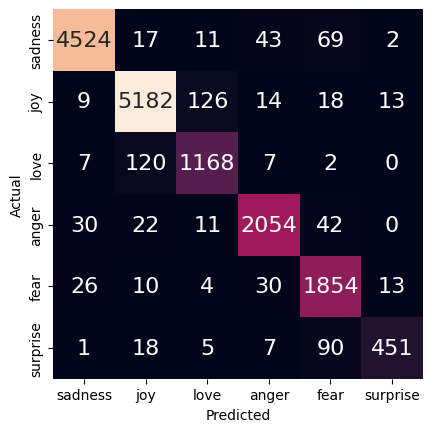

In [31]:
y_true_labels = np.argmax(test_y_one_hot, axis=1)

labels=['sadness','joy','love','anger','fear','surprise']
#labels = list(set(labels).intersection(set(np.unique(y_true_labels)).union(set(np.unique(y_pred_classes)))))

cm = confusion_matrix(y_true_labels, y_pred_classes)
df_cm = pd.DataFrame(cm, labels, labels)
ax = sns.heatmap(df_cm, annot=True, annot_kws={'size': 16}, square=True, cbar=False, fmt='g')
ax.set_ylim(0, 6) 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
ax.invert_yaxis() 
plt.show()


## accuracy_score, precision_score, recall_score, f1_scoreacy 

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model on the validation set
val_predictions = model.predict(val_X)
val_predictions = np.argmax(val_predictions, axis=1)
val_true = np.argmax(val_y_one_hot, axis=1)


# Calculate precision
precision = precision_score(val_true, val_predictions, average='weighted')
print("Precision:", precision)

# Calculate recall
recall = recall_score(val_true, val_predictions, average='weighted')
print("Recall:", recall)

# Calculate F1-score
f1 = f1_score(val_true, val_predictions, average='weighted')
print("F1-score:", f1)


94/94 [==============================] - 12s 46ms/step
Precision: 0.8772853353394445
Recall: 0.8763333333333333
F1-score: 0.8762625039274655


In [33]:
# Save model and tokenizer
import pickle
model.save("your_model.h5")
tokenizer_path = "your_tokenizer.pkl"
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer2, f)

e:\codebook\NLP\vnlp\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [36]:
import pickle
from keras.models import load_model

def predict_text(text, model_path, tokenizer_path, length_of_longest_sentence):
    # Load model
    model = load_model(model_path)
    
    # Load tokenizer
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)
    
    # Preprocess input text
    stemmed_words = [stemmer.stem(word) for word in text.split()]
    token_list = tokenizer.texts_to_sequences([stemmed_words])[0]
    padded_sequence = pad_sequences([token_list], maxlen=length_of_longest_sentence, padding='post')
    
    # Make prediction
    prediction = model.predict(padded_sequence)
    
    return prediction.argmax(axis=-1)

# Example usage
predicted_label = predict_text("feel running divine experience expect type spiritual encounter", "your_model.h5", "your_tokenizer.pkl",length_of_longest_sentence)
print(predicted_label)


1/1 [==============================] - 3s 3s/step
[1]


In [37]:
import pickle
from keras.models import load_model
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
from keras.preprocessing.sequence import pad_sequences

length_of_longest_sentence=66
def predict_text(text, model_path, tokenizer_path):
    # Load model
    model = load_model(model_path)
    
    # Load tokenizer
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)
    
    # Preprocess input text
    stemmed_words = [stemmer.stem(word) for word in text.split()]
    token_list = tokenizer.texts_to_sequences([stemmed_words])[0]
    padded_sequence = pad_sequences([token_list], maxlen=length_of_longest_sentence, padding='post')
    
    # Make prediction
    prediction = model.predict(padded_sequence)
    
    return prediction.argmax(axis=-1)

# Example usage
predicted_label = predict_text("stymied little bit wrote feeling unsure might go somewhere story unintended", "your_model.h5", "your_tokenizer.pkl")
print(predicted_label)

1/1 [==============================] - 1s 942ms/step
[4]


In [38]:
from keras.models import load_model
import pickle
from keras.preprocessing.sequence import pad_sequences
from nltk.stem import PorterStemmer

# Load tokenizer
tokenizer_path = "your_tokenizer.pkl"
with open(tokenizer_path, 'rb') as f:
    tokenizer = pickle.load(f)

# Load model
model = load_model("your_model.h5")

# Assuming you have 'length_of_longest_sentence'
length_of_longest_sentence = 100

def preprocess_text(text, tokenizer, length_of_longest_sentence):
    stemmer = PorterStemmer()
    stemmed_words = [stemmer.stem(word) for word in text.split()]
    token_list = tokenizer.texts_to_sequences([stemmed_words])[0]
    padded_sequence = pad_sequences([token_list], maxlen=length_of_longest_sentence, padding='post')
    return padded_sequence

# Function for prediction
def predict_label(text, model, tokenizer, length_of_longest_sentence):
    # Preprocess the text
    preprocessed_text = preprocess_text(text, tokenizer, length_of_longest_sentence)

    # Make prediction
    predictions = model.predict(preprocessed_text)

    return predictions

# Assuming you have a dictionary mapping label indices to emotions
labels_dict = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

# User input
user_input = "feel running divine experience expect type spiritual encounter"

# Predict label
predictions = predict_label(user_input, model, tokenizer, length_of_longest_sentence)

# Assuming you want to get the top 5 predictions
top_n = 5
top_n_predictions = (-predictions[0]).argsort()[:top_n]

# Printing the top predictions
print("Top", top_n, "predictions:")
for i in top_n_predictions:
    print("Emotion:", labels_dict[i], "Probability:", predictions[0][i])


1/1 [==============================] - 1s 1s/step
Top 5 predictions:
Emotion: joy Probability: 0.9999945
Emotion: love Probability: 5.242095e-06
Emotion: sadness Probability: 1.349058e-07
Emotion: anger Probability: 8.866124e-08
Emotion: fear Probability: 9.920288e-09


In [39]:
predictions[0][1]

0.9999945